In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [2]:
df = pd.read_csv("../../course_assignments/homework9/noisy_curvefit_data.csv")
df

,x,y_noise_1,y_noise_2,y_noise_3,y_noise_4,y_noise_5
0,-1.000000,11.624419,8.296963,12.201067,7.811725,3.155566
1,-0.929293,10.377466,9.674440,12.198084,8.275006,7.518855
2,-0.858586,10.585100,9.251983,13.186565,12.926586,9.963630
3,-0.787879,10.913928,7.786344,12.552304,11.832379,9.625801
4,-0.717172,8.640287,8.551869,4.741432,8.790834,6.624113
...,...,...,...,...,...,...
95,5.717172,-1.411918,0.822231,-2.027132,-1.825106,2.746147
96,5.787879,0.344879,-1.718956,2.747559,-6.803779,-5.137472
97,5.858586,0.307133,0.353528,0.967976,5.461567,-0.905616
98,5.929293,0.048657,0.159961,2.482130,-0.414616,-4.334548


In [3]:
df.shape
# The shape of the data set is 100 x 6
# This means there are 100 rows and 6 columns in the dataframe

(100, 6)

In [4]:
df.head()

,x,y_noise_1,y_noise_2,y_noise_3,y_noise_4,y_noise_5
0,-1.000000,11.624419,8.296963,12.201067,7.811725,3.155566
1,-0.929293,10.377466,9.674440,12.198084,8.275006,7.518855
2,-0.858586,10.585100,9.251983,13.186565,12.926586,9.963630
3,-0.787879,10.913928,7.786344,12.552304,11.832379,9.625801
4,-0.717172,8.640287,8.551869,4.741432,8.790834,6.624113


In [5]:
df.tail()

,x,y_noise_1,y_noise_2,y_noise_3,y_noise_4,y_noise_5
95,5.717172,-1.411918,0.822231,-2.027132,-1.825106,2.746147
96,5.787879,0.344879,-1.718956,2.747559,-6.803779,-5.137472
97,5.858586,0.307133,0.353528,0.967976,5.461567,-0.905616
98,5.929293,0.048657,0.159961,2.482130,-0.414616,-4.334548
99,6.000000,-0.193438,-2.244792,1.930035,4.992414,-6.872850


In [6]:
x = df.columns
for i in range(len(x)):
    print(x[i])
# Below are the column names

x
y_noise_1
y_noise_2
y_noise_3
y_noise_4
y_noise_5


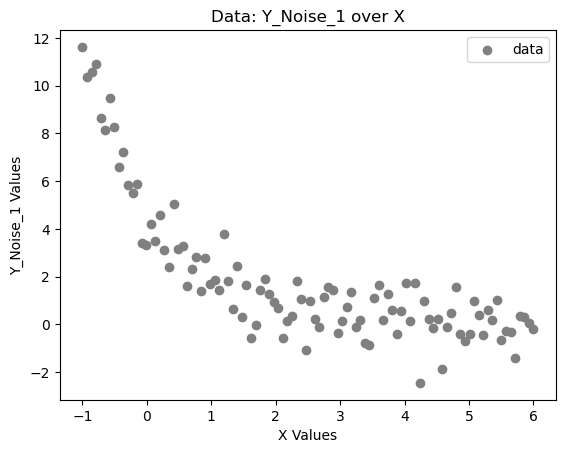

In [7]:
plt.figure()
plt.scatter(df["x"], df["y_noise_1"], color = "gray", label = "data")
plt.xlabel("X Values")
plt.ylabel("Y_Noise_1 Values")
plt.title("Data: Y_Noise_1 over X")
plt.legend()
plt.show()

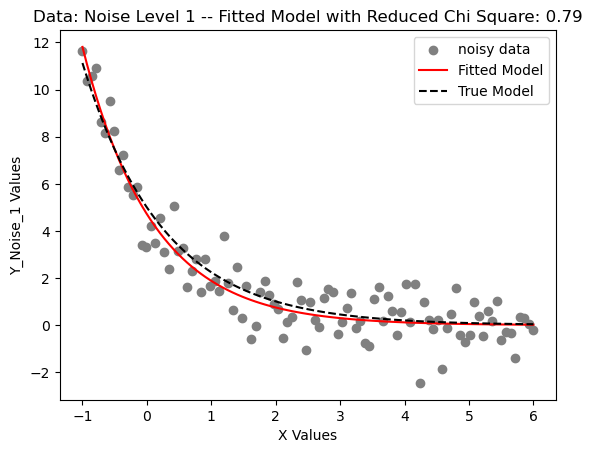

Fit: y = 4.71 * e^(-0.92 * x)
Reduced chi2_reduced: 0.79


In [8]:
def model(x, A, k):
    return A * np.exp(-k * x)

x = df["x"]
y = df["y_noise_1"]
p0 = [1,1]
popt, pcov = curve_fit(model, x, y, p0=p0)
A_fit, k_fit = popt
plt.scatter(x, y, color = "gray", label = "noisy data")
plt.plot(x, model(x, A_fit, k_fit), color = "red", label = "Fitted Model")
plt.plot(x, model(x, 5, 0.8), linestyle = "--", color = "black", label = "True Model")
plt.xlabel("X Values")
plt.ylabel("Y_Noise_1 Values")
plt.title("Data: Noise Level 1 -- Fitted Model with Reduced Chi Square: 0.79")
plt.legend()
plt.show()
print(f"Fit: y = {A_fit:.2f} * e^(-{k_fit:.2f} * x)")
residuals = y - model(x, A_fit, k_fit)
chi2 = np.sum(residuals**2)
dof = len(x) - len(popt)
chi2_reduced = chi2 / dof
print(f"Reduced chi2_reduced: {chi2_reduced:.2f}")

True fit: A: 5, k: 0.8
NL2 A_fit: 5.06388869738439, k_fit: 0.7303962611566385, Reduced Chi Squared 3.6493823840388626
NL3 A_fit: 5.6093960072277556, k_fit: 0.8703719511733142, Reduced Chi Squared 10.410207288349078
NL4 A_fit: 5.7387267381529385, k_fit: 0.7259648869040801, Reduced Chi Squared 12.626832435376498
NL5 A_fit: 4.943458473860519, k_fit: 0.6950119288003864, Reduced Chi Squared 28.538124369073678


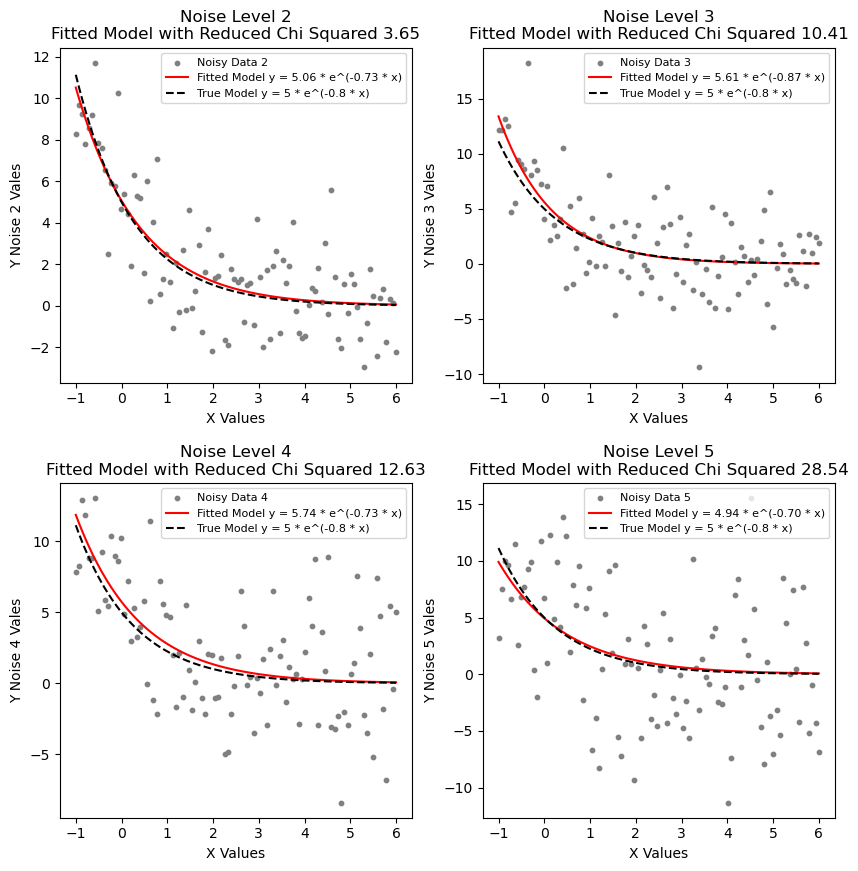

In [9]:
x = df["x"]
y1 = df["y_noise_1"]
y2 = df["y_noise_2"]
y3 = df["y_noise_3"]
y4 = df["y_noise_4"]
y5 = df["y_noise_5"]

def fit_model(x,y):
    def model(x, A, k):
        return A * np.exp(-k *x)
    p0 = [1,1]
    popt, pcov = curve_fit(model, x, y, p0=p0)
    A_fit, k_fit = popt
    # print(f"Fit: y = {A_fit:.2f} * e^(-{k_fit:.2f} * x)")
    residuals = y - model(x, A_fit, k_fit)
    chi2 = np.sum(residuals**2)
    dof = len(x) - len(popt)
    chi2_reduced_ = chi2 / dof
    # print(f"Reduced chi2_reduced: {chi2_reduced:.2f}")
    return [A_fit, k_fit, chi2_reduced_]

y2_thru_y5 = [y2, y3, y4, y5]


fig, ax = plt.subplots(2,2, figsize = (10,10))

plt.subplots_adjust(hspace=0.3)
print("True fit: A: 5, k: 0.8")
for i, y in zip(range(4), y2_thru_y5):
    row = i // 2
    column = i % 2
    A__fit = fit_model(x,y)[0]
    k__fit = fit_model(x,y)[1]
    chi2__reduced = fit_model(x,y)[2]
    print(f"NL{i+2} A_fit: {A__fit}, k_fit: {k__fit}, Reduced Chi Squared {chi2__reduced}")
    ax[row, column].scatter(x, y, color = "gray", label = f"Noisy Data {i+2}", s=10)
    ax[row, column].plot(x, model(x, A__fit, k__fit), color = "red", label = f"Fitted Model y = {A__fit:.2f} * e^(-{k__fit:.2f} * x)")
    ax[row, column].plot(x, model(x, 5, 0.8), linestyle = "--", color = "black", label = "True Model y = 5 * e^(-0.8 * x)")
    ax[row, column].set_xlabel("X Values")
    ax[row, column].set_ylabel(f"Y Noise {i + 2} Vales")
    ax[row, column].set_title(f"Noise Level {i + 2}\nFitted Model with Reduced Chi Squared {chi2__reduced:.2f}", fontsize = 12)
    ax[row, column].legend(fontsize = 8)
plt.show()

# As the noise level increases, the fitted model (red line) gets further away from the true model 
# (i.e. compared to the true value (5) for A, the model value diverages: 5.06, then 5.61, 5.74, then 4.94)
# This is because the data gets more sporadic as the noise level increases, so the approximation has less reliable data
# to base off of, so the appromization becomes less accurate.
# As as the noise level increased, the reduced chi squared increases (from 3 to 10 to 12, then 28)
# This is because, as explained above, the fitted model becomes less and less acurate and thus the "error," given by
# reduced chi squared, increases.

In [13]:
y_noise_1_to_5 = [y1,y2,y3,y4,y5]

data = {"Noise Level": [],
        "A fit": [],
        "k fit": [],
        "Reduced chi-squared": []}

for i in range(5):
        data["Noise Level"].append(i + 1)
for y in y_noise_1_to_5:
    data["A fit"].append(fit_model(x,y)[0])
    data["k fit"].append(fit_model(x,y)[1])
    data["Reduced chi-squared"].append(fit_model(x,y)[2])

df = pd.DataFrame(data)
df

,Noise Level,A fit,k fit,Reduced chi-squared
0,1,4.714814,0.918308,0.790673
1,2,5.063889,0.730396,3.649382
2,3,5.609396,0.870372,10.410207
3,4,5.738727,0.725965,12.626832
4,5,4.943458,0.695012,28.538124


In [14]:
df.to_csv("noisy_parameters.csv", index=False)